#Import Relevant Classes

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
!pip install scikit-optimize
from skopt import BayesSearchCV
%matplotlib inline
from sklearn.preprocessing import StandardScaler
from google.colab import drive

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.3/100.3 kB 6.6 MB/s eta 0:00:00


#Load the Data

In [ ]:
drive.mount('/content/drive')
path = "/content/drive/MyDrive/train.csv"
df_train = pd.read_csv(path, index_col = 0)
path_test = '/content/drive/MyDrive/test.csv'
df_test = pd.read_csv(path_test, index_col = 0)

Mounted at /content/drive


#Exploratory Data Analysis

In [ ]:
df_train

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
PassengerId,,,,,,,,,,,,,
0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True


In [ ]:
df_train.isnull().sum()
df_test.isnull().sum()

HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

In [ ]:
df_train = df_train.dropna(axis = 0)


In [ ]:
df_train.isnull().sum()

HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64

In [ ]:
df_test.isnull().sum()

HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

In [ ]:
df_train

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
PassengerId,,,,,,,,,,,,,
0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True


In [ ]:
df_train['HomePlanet'].value_counts()

Earth     3566
Europa    1673
Mars      1367
Name: HomePlanet, dtype: int64

In [ ]:
encoded = pd.get_dummies(df_train, columns = ['HomePlanet',"Destination"], drop_first = True)

<__array_function__ internals>:180: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
<__array_function__ internals>:180: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
<__array_function__ internals>:180: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.


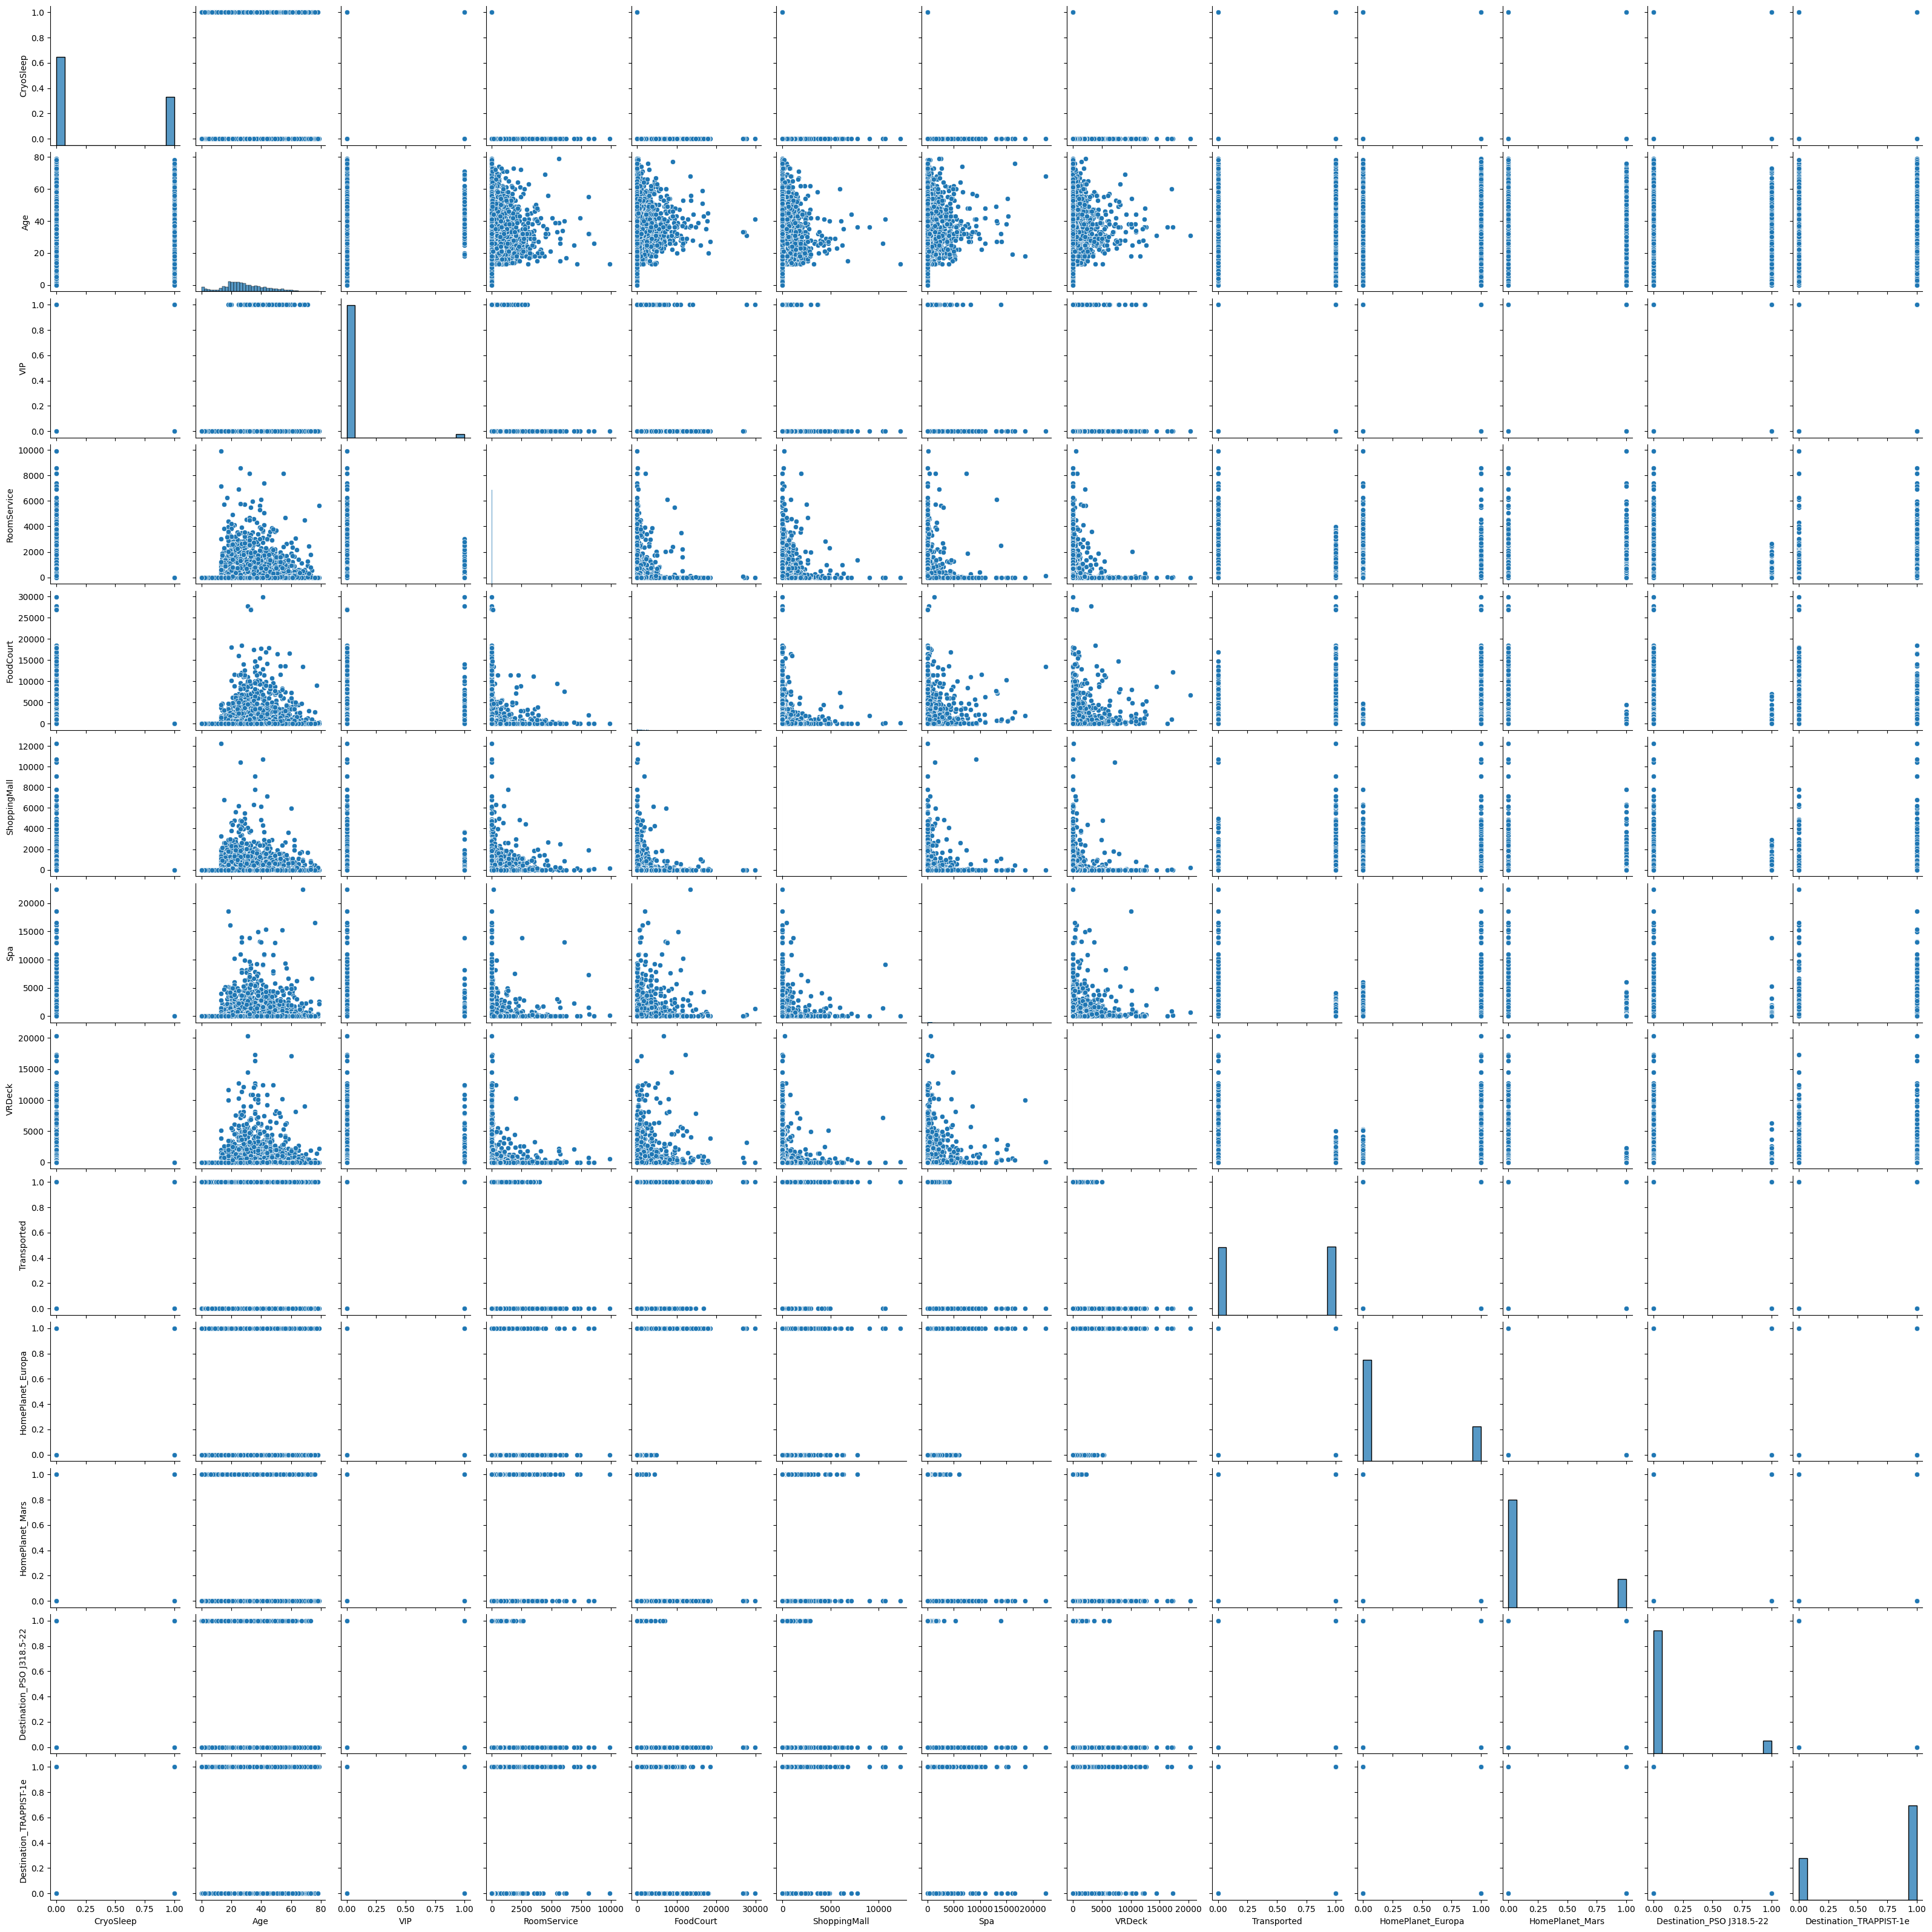

In [ ]:
sns.pairplot(data = encoded)

<Axes: >

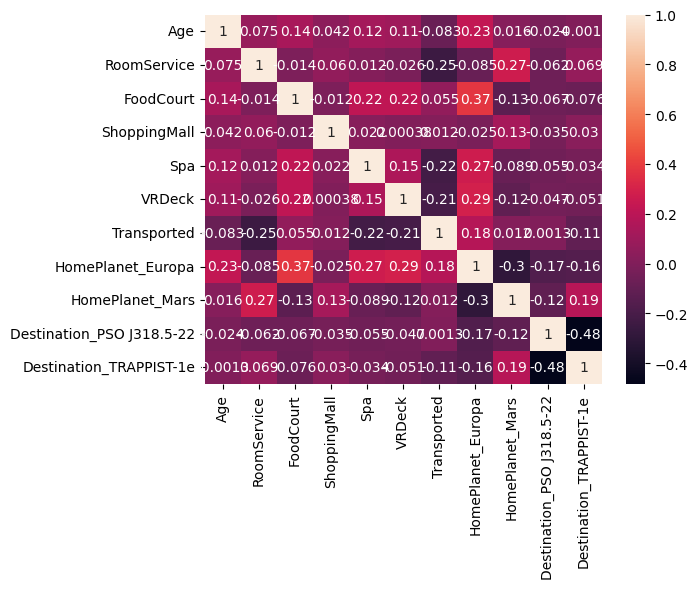

In [ ]:
sns.heatmap(encoded.corr(numeric_only = True), annot = True)

I found that the strongest correlation(number closest to 1) was between the people transported and people who's homeplanet was Europa. The people who were Transported also had an inverse correlation with the people with Room Service. The pairplot wasn't as useful, but the heatmap was. The data was only useful once dropping all the null values, but that ended up dropping entire rows, resulting in 2000 rows of missing data; to resolve this issue, I used one hot encoding and changed all the boolean values to 0 and 1, and the Cabin Name ending in 'P' to 0 and 'S' to 1. After this, the data was ready to be used, which I ended up using the random forest classifier as well as a hyper-parameter turning method (Bayesian and GridSearch methods).

# Feature Generation / Data Processing

In [ ]:
test_encoded = pd.get_dummies(df_test, columns = ['HomePlanet',"Destination"], drop_first = True)

In [ ]:
test_encoded

,CryoSleep,Cabin,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,HomePlanet_Europa,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
PassengerId,,,,,,,,,,,,,,
0013_01,True,G/3/S,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning,0,0,0,1
0018_01,False,F/4/S,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers,0,0,0,1
0019_01,True,C/0/S,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus,1,0,0,0
0021_01,False,C/1/S,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter,1,0,0,1
0023_01,False,F/5/S,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9266_02,True,G/1496/S,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter,0,0,0,1
9269_01,False,NaN,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron,0,0,0,1
9271_01,True,D/296/P,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore,0,1,0,0


In [ ]:
def test(index):
  cabin = encoded['Cabin'][index].split('/')
  if cabin[2] == 'S':
    encoded['Cabin'][index] = 1
  elif cabin[2] == 'P':
    encoded['Cabin'][index] = 0

for x in range(0,6606):
  test(x)
encoded['Cabin'].value_counts()

<ipython-input-18-132503911d53>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  encoded['Cabin'][index] = 0
<ipython-input-18-132503911d53>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  encoded['Cabin'][index] = 1


1    3345
0    3261
Name: Cabin, dtype: int64

In [ ]:
test_encoded['Cabin']=test_encoded['Cabin'].fillna(test_encoded['Cabin'].mode()[0])

In [ ]:
test_encoded.isnull().sum()

CryoSleep                     93
Cabin                          0
Age                           91
VIP                           93
RoomService                   82
FoodCourt                    106
ShoppingMall                  98
Spa                          101
VRDeck                        80
Name                          94
HomePlanet_Europa              0
HomePlanet_Mars                0
Destination_PSO J318.5-22      0
Destination_TRAPPIST-1e        0
dtype: int64

In [ ]:
test_encoded['CryoSleep'] = test_encoded['CryoSleep'].fillna(test_encoded['CryoSleep'].mode()[0])

In [ ]:
test_encoded['Age'] = test_encoded['Age'].fillna(test_encoded['Age'].mean())
test_encoded['VIP'] = test_encoded['VIP'].fillna(test_encoded['VIP'].mean())
test_encoded['RoomService']=test_encoded['RoomService'].fillna(test_encoded['RoomService'].mean())
test_encoded['FoodCourt'] = test_encoded['FoodCourt'].fillna(test_encoded['FoodCourt'].mean())
test_encoded['ShoppingMall'] = test_encoded['ShoppingMall'].fillna(test_encoded['ShoppingMall'].mean())
test_encoded['Spa'] = test_encoded['Spa'].fillna(test_encoded['Spa'].mean())
test_encoded['VRDeck'] = test_encoded['VRDeck'].fillna(test_encoded['VRDeck'].mean())


In [ ]:
test_encoded.isnull().sum()

CryoSleep                     0
Cabin                         0
Age                           0
VIP                           0
RoomService                   0
FoodCourt                     0
ShoppingMall                  0
Spa                           0
VRDeck                        0
Name                         94
HomePlanet_Europa             0
HomePlanet_Mars               0
Destination_PSO J318.5-22     0
Destination_TRAPPIST-1e       0
dtype: int64

In [ ]:
def test_data_test(index):
  cabin = test_encoded['Cabin'][index].split('/')
  if cabin[2] == 'S':
    test_encoded['Cabin'][index] = 1
  elif cabin[2] == 'P':
    test_encoded['Cabin'][index] = 0

for x in range(0,4277):
  test_data_test(x)
test_encoded['Cabin'].value_counts()

<ipython-input-24-2250992e666a>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_encoded['Cabin'][index] = 1
<ipython-input-24-2250992e666a>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_encoded['Cabin'][index] = 0


0    2184
1    2093
Name: Cabin, dtype: int64

In [ ]:
test_encoded.isnull().sum()

CryoSleep                     0
Cabin                         0
Age                           0
VIP                           0
RoomService                   0
FoodCourt                     0
ShoppingMall                  0
Spa                           0
VRDeck                        0
Name                         94
HomePlanet_Europa             0
HomePlanet_Mars               0
Destination_PSO J318.5-22     0
Destination_TRAPPIST-1e       0
dtype: int64

In [ ]:
encoded['Cabin'].value_counts()

1    3345
0    3261
Name: Cabin, dtype: int64

# Model Training + Hyperparameter Tuning

In [ ]:
encoded

,CryoSleep,Cabin,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,HomePlanet_Europa,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
PassengerId,,,,,,,,,,,,,,,
0001_01,False,0,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,1,0,0,1
0002_01,False,1,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,0,0,0,1
0003_01,False,1,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,1,0,0,1
0003_02,False,1,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,1,0,0,1
0004_01,False,1,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9276_01,False,0,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False,1,0,0,0
9278_01,True,1,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False,0,0,1,0
9279_01,False,1,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True,0,0,0,1


In [ ]:
nobool = encoded.drop('Name', axis = 1, inplace = True)
nobool = pd.get_dummies(encoded, columns = ['CryoSleep','VIP','Transported'], drop_first = True)
test_nobool = pd.get_dummies(test_encoded, columns = ['CryoSleep','VIP'], drop_first = True)

In [ ]:
test_nobool.drop('Name', axis = 1, inplace = True)
test_nobool.isnull().sum()

Cabin                        0
Age                          0
RoomService                  0
FoodCourt                    0
ShoppingMall                 0
Spa                          0
VRDeck                       0
HomePlanet_Europa            0
HomePlanet_Mars              0
Destination_PSO J318.5-22    0
Destination_TRAPPIST-1e      0
CryoSleep_True               0
VIP_0.01768642447418738      0
VIP_True                     0
dtype: int64

In [ ]:
test_nobool.drop('VIP_0.01768642447418738', axis = 1, inplace = True)

In [ ]:
test_nobool

,Cabin,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Europa,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,CryoSleep_True,VIP_True
PassengerId,,,,,,,,,,,,,
0013_01,1,27.000000,0.0,0.0,0.0,0.0,0.0,0,0,0,1,1,0
0018_01,1,19.000000,0.0,9.0,0.0,2823.0,0.0,0,0,0,1,0,0
0019_01,1,31.000000,0.0,0.0,0.0,0.0,0.0,1,0,0,0,1,0
0021_01,1,38.000000,0.0,6652.0,0.0,181.0,585.0,1,0,0,1,0,0
0023_01,1,20.000000,10.0,0.0,635.0,0.0,0.0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9266_02,1,34.000000,0.0,0.0,0.0,0.0,0.0,0,0,0,1,1,0
9269_01,0,42.000000,0.0,847.0,17.0,10.0,144.0,0,0,0,1,0,0
9271_01,0,28.658146,0.0,0.0,0.0,0.0,0.0,0,1,0,0,1,0


In [ ]:
nobool

,Cabin,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Europa,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,CryoSleep_True,VIP_True,Transported_True
PassengerId,,,,,,,,,,,,,,
0001_01,0,39.0,0.0,0.0,0.0,0.0,0.0,1,0,0,1,0,0,0
0002_01,1,24.0,109.0,9.0,25.0,549.0,44.0,0,0,0,1,0,0,1
0003_01,1,58.0,43.0,3576.0,0.0,6715.0,49.0,1,0,0,1,0,1,0
0003_02,1,33.0,0.0,1283.0,371.0,3329.0,193.0,1,0,0,1,0,0,0
0004_01,1,16.0,303.0,70.0,151.0,565.0,2.0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9276_01,0,41.0,0.0,6819.0,0.0,1643.0,74.0,1,0,0,0,0,1,0
9278_01,1,18.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0,1,0,0
9279_01,1,26.0,0.0,0.0,1872.0,1.0,0.0,0,0,0,1,0,0,1


In [ ]:
test_nobool.isnull().sum()

Cabin                        0
Age                          0
RoomService                  0
FoodCourt                    0
ShoppingMall                 0
Spa                          0
VRDeck                       0
HomePlanet_Europa            0
HomePlanet_Mars              0
Destination_PSO J318.5-22    0
Destination_TRAPPIST-1e      0
CryoSleep_True               0
VIP_True                     0
dtype: int64

###NEURAL NETWORKS

In [ ]:
import torch
from torch import nn
import torch.optim as optim

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(nobool.drop('Transported_True', axis = 1), nobool['Transported_True'], test_size = 0.3, random_state = 101)

In [ ]:
X_train

,Cabin,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Europa,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,CryoSleep_True,VIP_True
PassengerId,,,,,,,,,,,,,
2755_01,0,36.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,1,0
6224_01,1,16.0,0.0,0.0,60.0,0.0,1963.0,0,0,0,1,0,0
8884_01,0,26.0,1471.0,0.0,7.0,5.0,0.0,0,0,0,1,0,0
0933_02,0,29.0,0.0,1127.0,0.0,1867.0,1070.0,1,0,0,1,0,0
6338_01,0,16.0,0.0,0.0,694.0,0.0,102.0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
0835_01,1,14.0,77.0,0.0,9.0,424.0,166.0,0,0,0,0,0,0
8049_01,0,22.0,6.0,21.0,0.0,782.0,0.0,0,0,0,1,0,0
1947_01,1,21.0,942.0,0.0,0.0,0.0,7.0,0,0,0,1,0,0


In [ ]:
X_train_mean = np.mean(X_train)
X_train_std = np.std(X_train)
X_train_norm = (X_train - X_train_mean)/X_train_std

X_test_mean = np.mean(X_test)
X_test_std = np.std(X_test)
X_test_norm = (X_test - X_test_mean)/X_test_std

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3472: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3472: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


In [ ]:
X_train_norm

,Cabin,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Europa,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,CryoSleep_True,VIP_True
PassengerId,,,,,,,,,,,,,
2755_01,-1.006509,0.482106,-0.340881,-0.280377,-0.304664,-0.274972,-0.267958,1.736056,-0.510185,-0.323064,-1.500586,1.363678,-0.158988
6224_01,0.993533,-0.887427,-0.340881,-0.280377,-0.203157,-0.274972,1.534578,-0.576018,-0.510185,-0.323064,0.666406,-0.733311,-0.158988
8884_01,-1.006509,-0.202661,1.861322,-0.280377,-0.292821,-0.270521,-0.267958,-0.576018,-0.510185,-0.323064,0.666406,-0.733311,-0.158988
0933_02,-1.006509,0.002769,-0.340881,0.374377,-0.304664,1.387211,0.714576,1.736056,-0.510185,-0.323064,0.666406,-0.733311,-0.158988
6338_01,-1.006509,-0.887427,-0.340881,-0.280377,0.869434,-0.274972,-0.174296,-0.576018,-0.510185,-0.323064,-1.500586,-0.733311,-0.158988
...,...,...,...,...,...,...,...,...,...,...,...,...,...
0835_01,0.993533,-1.024380,-0.225606,-0.280377,-0.289438,0.102513,-0.115527,-0.576018,-0.510185,-0.323064,-1.500586,-0.733311,-0.158988
8049_01,-1.006509,-0.476567,-0.331899,-0.268176,-0.304664,0.421239,-0.267958,-0.576018,-0.510185,-0.323064,0.666406,-0.733311,-0.158988
1947_01,0.993533,-0.545044,1.069367,-0.280377,-0.304664,-0.274972,-0.261530,-0.576018,-0.510185,-0.323064,0.666406,-0.733311,-0.158988


In [ ]:
X_train_norm.values.dtype

dtype('O')

In [ ]:
X_train = torch.tensor(X_train_norm.values.astype(np.float), dtype=torch.float)
y_train = torch.tensor(y_train.values.astype(np.long), dtype=torch.long)
X_test = torch.tensor(X_test_norm.values.astype(np.float), dtype=torch.float)
y_test = torch.tensor(y_test.values.astype(np.long), dtype=torch.long)

<ipython-input-98-1a974dd8ab29>:1: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  X_train = torch.tensor(X_train_norm.values.astype(np.float), dtype=torch.float)
<ipython-input-98-1a974dd8ab29>:2: DeprecationWarning: `np.long` is a deprecated alias for `np.compat.long`. To silence this warning, use `np.compat.long` by itself. In the likely event your code does not need to work on Python 2 you can use the builtin `int` for which `np.compat.long` is itself an alias. Doing this will not modify any behaviour and is safe. When replacing `np.long`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check 

In [ ]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    super(NeuralNetwork, self).__init__()
    self.hidden1 = nn.Linear(X_train.shape[1], 16)
    self.hidden2 = nn.Linear(16, 2)

  def forward(self, x):
    x = torch.relu(self.hidden1(x))
    x = self.hidden2(x)
    return x

In [ ]:
model = NeuralNetwork()
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)
print(model)

NeuralNetwork(
  (hidden1): Linear(in_features=13, out_features=16, bias=True)
  (hidden2): Linear(in_features=16, out_features=2, bias=True)
)


In [ ]:
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
train_data = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_data, batch_size = 32)

In [ ]:
epochs = 100
loss_list = np.zeros((epochs,))

for epoch in range(epochs):
  running_loss = 0
  for inputs, targets in train_loader:
    optimizer.zero_grad() # reset optimizer gradients
    outputs = model(inputs) # forward pass data through nodes/layers
    loss = loss_fn(outputs, targets) # compute loss
    loss_list[epoch] = loss.item()
    running_loss += loss.item()
    loss.backward() # backprop
    optimizer.step() # update weighst

  if epoch % 10 == 0:
    print(f'Epoch [{epoch}/100], Loss: {running_loss/len(train_loader)}')

Epoch [0/100], Loss: 0.7279177279307925
Epoch [10/100], Loss: 0.6620126300844653
Epoch [20/100], Loss: 0.6159406431790055
Epoch [30/100], Loss: 0.5702076089793238
Epoch [40/100], Loss: 0.5298847669157488
Epoch [50/100], Loss: 0.49988849245268724
Epoch [60/100], Loss: 0.4801120844380609
Epoch [70/100], Loss: 0.46738408331213327
Epoch [80/100], Loss: 0.45887281976897143
Epoch [90/100], Loss: 0.4526865314820717


In [ ]:
with torch.no_grad():
  out = model(X_test)
  _, predicted = torch.max(out.data, 1)
  total = y_test.size(0)
  correct = (predicted == y_test).sum().item()
  print("Accuracy of the model based on y_test: {}%".format((100 * correct/total //1)))



Accuracy of the model based on y_test: 79.0%


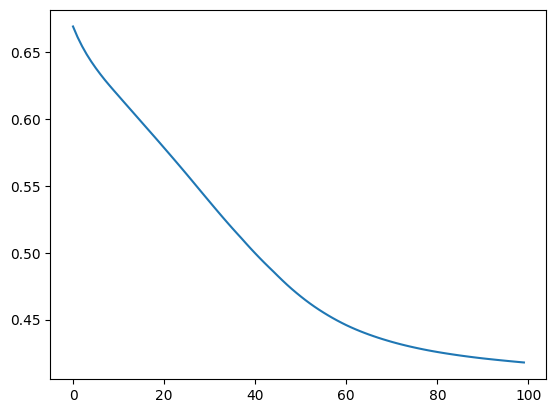

In [ ]:
plt.plot(loss_list)
plt.show()

In [ ]:
df_final= pd.read_csv(path_test)

new_arr = np.where(predictions == 1, True, False)


df_final['Transported'] = new_arr
df_final[['PassengerId', 'Transported']].to_csv('/content/drive/MyDrive/BlastAIKaggle.csv', encoding='utf-8', index=False)
